In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [4]:
from utils.cart import make_wcs, to_cart

In [5]:
cmap = 'RdBu_r'

In [6]:
! nvidia-smi

Wed Mar 23 15:01:24 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.57.02    Driver Version: 470.57.02    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:06:00.0 Off |                    0 |
| N/A   36C    P0    26W / 250W |      0MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  Tesla V100-PCIE...  On   | 00000000:2F:00.0 Off |                    0 |
| N/A   

## Simulations

In [7]:
extent = 25
n_pixels = 96
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [8]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0


In [9]:
mesh_dim = np.linspace(0, n_pixels, (n_pixels + 1) * upsample_factor)
interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_gce_cart)
temp_gce_cart_upsampled = interp(mesh_dim, mesh_dim)

In [10]:
from models.scd import dnds

In [11]:
n_sim = 30000

prior_ps = [[0.001, 10.0, 1.1, -10.0, 5.0, 1., 0.001, 10.0, 1.1, -10.0, 5.0, 1.], 
            [2., 20.0, 1.99, 1.99, 40.0, 4.99, 2., 20.0, 1.99, 1.99, 40.0, 4.99]]

prior_poiss = [[0.001, 0.001, 0.001, 0.001, 6.0, 1.0], 
               [2., 1.5, 1.5, 1.5, 12.0, 6.0]]

temps_ps = np.array([temp_gce_cart, temp_dsk_cart])
temps_poiss = np.array([temp_gce_cart, temp_iso_cart, temp_bub_cart, temp_psc_cart, temp_mO_pibrem_cart, temp_mO_ics_cart])

temps_ps_upsampled = []

for temp_ps in temps_ps:
    interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_ps)
    temp_ps_upsampled = interp(mesh_dim, mesh_dim)
    temps_ps_upsampled.append(temp_ps_upsampled)

thetas = np.random.uniform(low=prior_poiss[0] + prior_ps[0], high=prior_poiss[1] + prior_ps[1], size=(n_sim, len(prior_ps[0]) + len(prior_poiss[0])))

In [12]:
from tqdm.notebook import tqdm

In [14]:
s_ary = np.logspace(-1, 2, 1000)
logs_ary = np.log10(s_ary)
dlogs_ary = np.diff(logs_ary)[0] # Spacing in log-space

s_for_ds_ary = np.logspace(logs_ary[0] - dlogs_ary / 2.0, logs_ary[-1] + dlogs_ary / 2.0, len(s_ary) + 1)
ds_ary = np.diff(s_for_ds_ary)

signal_ensemble = np.zeros((n_sim, n_pixels, n_pixels))
flux_fraction = np.zeros((n_sim, len(temps_ps) + len(temps_poiss)))
dnds_ary = []

for idx_theta, theta in enumerate(tqdm(thetas)):

    idx_theta_ps = len(temps_poiss)
    
    for idx, temp_ps in enumerate(temps_ps):

        dnds_ary_temp = dnds(s_ary, theta[idx_theta_ps:idx_theta_ps + 6])
        s_exp = np.trapz(s_ary * dnds_ary_temp, s_ary)
        dnds_ary_temp *= theta[idx_theta_ps] * np.prod(temp_ps.shape) / s_exp
        dnds_ary.append(dnds_ary_temp)
        idx_theta_ps += 6

        n_ps = np.random.poisson(np.trapz(dnds_ary_temp, s_ary))

        # Sample, accounting for dS factor for log-space sampling
        sample = PDFSampler(s_ary, ds_ary * dnds_ary_temp)(n_ps)

        dist = temps_ps_upsampled[idx]
        dist /= dist.sum() 
        pairs = np.indices(dimensions=temps_ps_upsampled[idx].shape).T # here are all of the x,y pairs 
        inds = np.random.choice(np.arange(np.prod(temps_ps_upsampled[idx].shape)),p=dist.reshape(-1),size=n_ps,replace=True)
        selections = pairs.reshape(-1, 2)[inds]
        hist = np.histogram2d(x=selections[:, 1], y=selections[:, 0], bins=n_pixels * upsample_factor, weights=sample)[0]
        
        signal = np.random.poisson(gaussian_filter(hist, sigma=sigma_psf / (pixelsize / upsample_factor), truncate=8.))

        b = signal.shape[0] // upsample_factor
        signal_reshaped = signal.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

        signal_ensemble[idx_theta, :, :] += signal_reshaped
        
        flux_fraction[idx_theta, idx] = signal_reshaped.mean()
        
    flux_fraction[idx_theta, 2:] = (temps_poiss.T * theta[:len(temps_poiss)]).mean((0,1))
    signal_ensemble[idx_theta, :, :] += np.random.poisson(np.einsum('i,ijk->jk', theta[:len(temps_poiss)], temps_poiss))
    
flux_fraction = (flux_fraction.T / flux_fraction.sum(1)).T

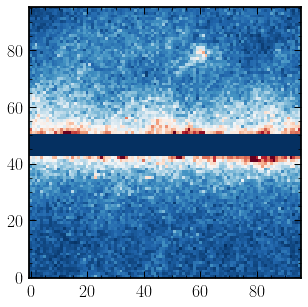

In [56]:
plt.imshow(signal_ensemble[2] * ~mask_roi, vmin=0, vmax=100, origin='lower', cmap=cmap)

In [57]:
np.savez("data.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)

## Generative model

In [13]:
data = np.load("data.npz")
signal_ensemble = data["signal_ensemble"]
flux_fraction = data["flux_fraction"]

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping

from models.glow import Glow
from models.glow.module import GlowPL

In [15]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [16]:
x = torch.Tensor(signal_ensemble).unsqueeze(1)
y = torch.Tensor(flux_fraction)

In [17]:
# x = torch.Tensor(~mask_roi).unsqueeze(0).unsqueeze(0) * x

In [18]:
x.max()

tensor(2616.)

In [19]:
val_fraction = 0.10
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=128, num_workers=0, pin_memory=False, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=128, num_workers=0, pin_memory=False, shuffle=False)

In [20]:
model = GlowPL(num_channels=256, num_levels=5, num_steps=18, quants=x.max() + 1)

In [ ]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
lr_monitor = LearningRateMonitor(logging_interval='epoch')

In [ ]:
trainer = pl.Trainer(max_epochs=10, gpus=4, strategy="ddp_spawn_find_unused_parameters_false", gradient_clip_val=1., callbacks=[checkpoint_callback, lr_monitor])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/4
initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/4
initializing distributed: GLOBAL_RANK: 2, MEMBER: 3/4
initializing distributed: GLOBAL_RANK: 3, MEMBER: 4/4
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 4 processes
----------------------------------------------------------------------------------------------------

Set SLURM handle signals.
Set SLURM handle signals.
Set SLURM handle signals.
Set SLURM handle signals.

  | Name | Type    | Params
---------------------------------
0 | flow | Glow    | 13.8 M
1 | loss | NLLLoss | 0     
---------------------------------
13.8 M    Trainable params
0         Non-trainable params
13.8 M    Total para

Epoch 0:  90%|████████▉ | 53/59 [01:35<00:10,  1.80s/it, loss=1.01e+05, v_num=575265]
Validating: 0it [00:00, ?it/s]
Epoch 1:  92%|█████████▏| 54/59 [01:33<00:08,  1.74s/it, loss=9.99e+04, v_num=575265]
Validating: 0it [00:00, ?it/s]
Epoch 2:  12%|█▏        | 7/59 [00:12<01:32,  1.77s/it, loss=9.99e+04, v_num=575265] 

In [22]:
checkpoint_callback.best_model_path

'/net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/lightning_logs/version_575265/checkpoints/epoch=14-step=794.ckpt'

In [57]:
model.load_from_checkpoint(checkpoint_callback.best_model_path, num_channels=256, num_levels=5, num_steps=18, quants=x.max() + 1);

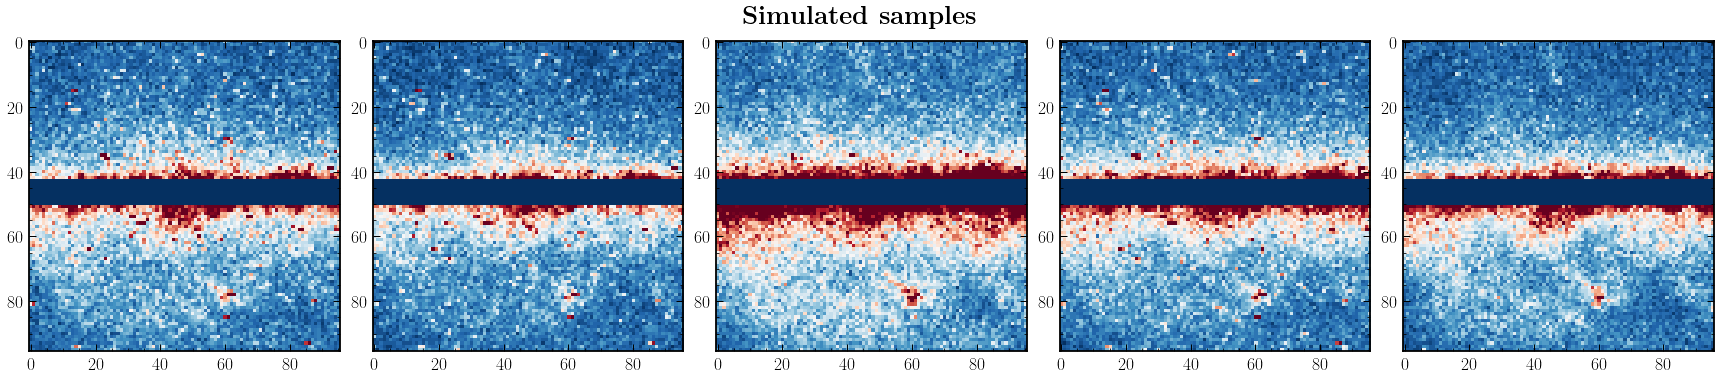

In [58]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy() * ~mask_roi, cmap=cmap, vmax=50)
    
plt.suptitle(r"\textbf{Simulated samples}", fontsize=26, y=0.9)
plt.tight_layout()

In [59]:
z = torch.randn(size=(5, 1, 96, 96))
x_samples, sldj = model.flow(z, reverse=True)

In [60]:
model.eval();

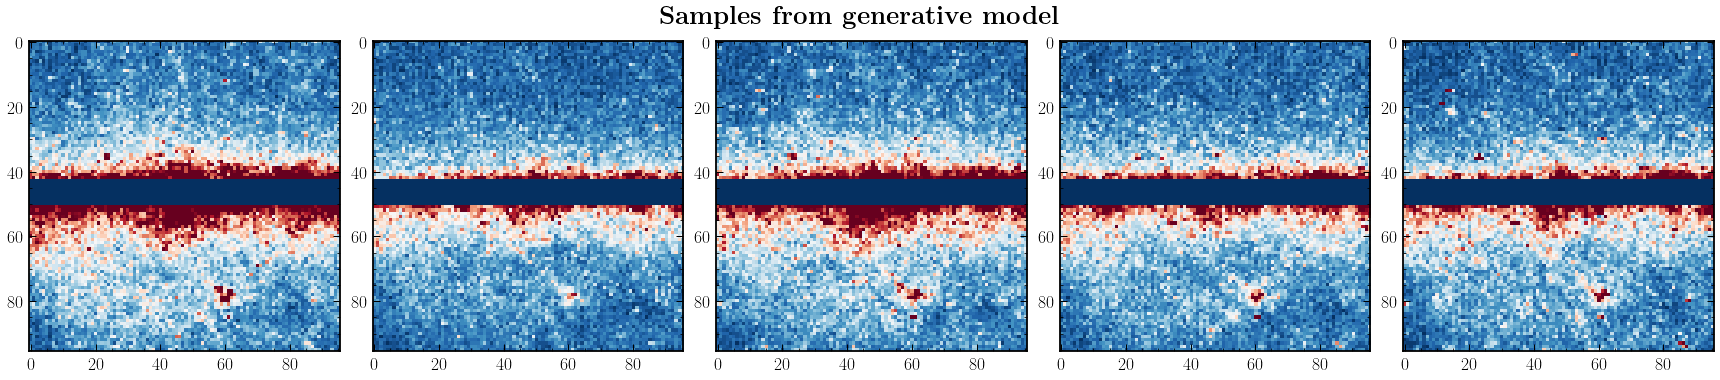

In [61]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy() * ~mask_roi, cmap=cmap, vmax=50)
    
plt.suptitle(r"\textbf{Samples from generative model}", fontsize=26, y=0.9)
plt.tight_layout()

## Test summaries

In [78]:
x_samples = torch.zeros(500, 1, 96, 96)
for i in tqdm(range(500)):
    z = torch.randn(size=(1, 1, 96, 96))
    x_samples[i, :] = model.flow(z, reverse=True)[0][0]

  0%|          | 0/500 [00:00<?, ?it/s]

In [79]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=128):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

In [80]:
x_pspec_samples = np.array([power_spectrum(x_i) for x_i in x_samples[:, 0, :, :]])
x_pspec_train = np.array([power_spectrum(x_i) for x_i in x[:500, 0]])

x_hist_samples = np.array([counts_histogram(x_i) for x_i in x_samples])
x_hist_train = np.array([counts_histogram(x_i) for x_i in x[:500, 0]])

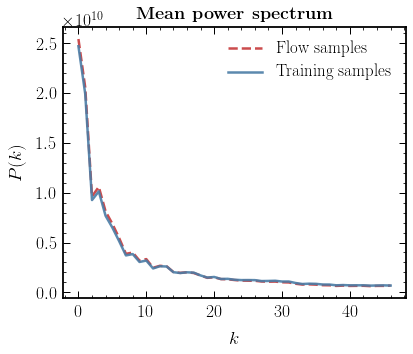

In [83]:
plt.plot(np.nanmean(x_pspec_samples, axis=0)[1:], label="Flow samples", ls='--')
plt.plot(np.mean(x_pspec_train, axis=0)[1:], label="Training samples")

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title(r"\textbf{Mean power spectrum}")
         
plt.legend()

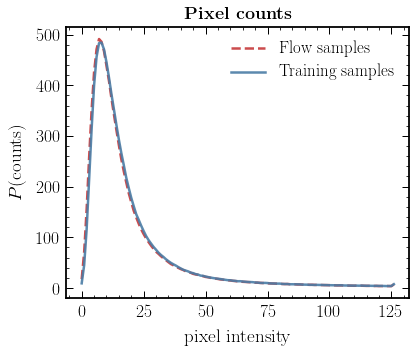

In [84]:
plt.plot(np.nanmean(x_hist_samples, axis=0), label="Flow samples", ls='--')
plt.plot(np.mean(x_hist_train, axis=0), label="Training samples")

plt.xlabel("pixel intensity")
plt.ylabel("$P(\mathrm{counts})$")
plt.title(r"\textbf{Pixel counts}")
         
plt.legend()

## Interpolating in the latent space

In [ ]:
def z_interp(z1, z2, weight=0.5):
    z_interp = torch.lerp(z1, z2, weight)
    return z_interp

In [40]:
z, _ = model.flow(x[5:7])

In [41]:
vrange = 50

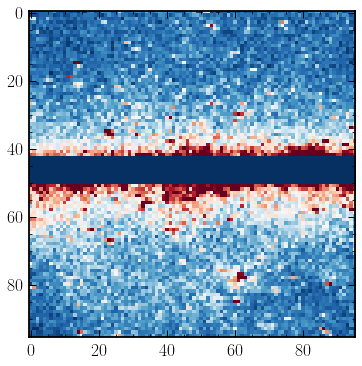

In [42]:
from celluloid import Camera

n_interp = 100

weights_ary = np.linspace(0, 1, n_interp)

fig = plt.figure(figsize=(6,6))

camera = Camera(fig)

for i in range(n_interp):
    
    x_dec = model.flow(z_interp(z[0], z[1], weight=weights_ary[i]).unsqueeze(0), reverse=True)[0]
    
    plt.imshow(x_dec[0,0].detach().numpy() * ~mask_roi, cmap=cmap, vmin=0, vmax=vrange)
    
    camera.snap()

In [43]:
animation = camera.animate()

In [44]:
from IPython.display import HTML
HTML(animation.to_html5_video())

In [45]:
animation.save('latent_interp.gif', fps=15)

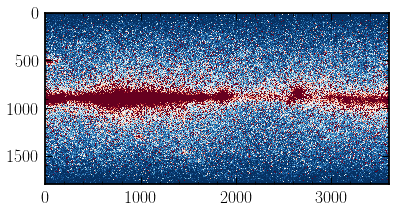

In [117]:
from astropy.io import fits

plt.imshow(fits.open("/n/holyscratch01/iaifi_lab/yitians/fluxcube_ultracleanveto_bestpsf_joined.fits")[0].data.sum(0), vmax=1e-9, cmap=cmap)

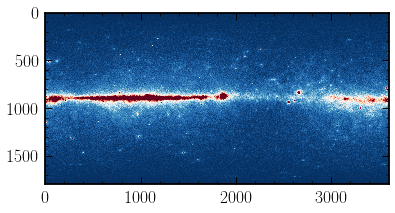

In [119]:
plt.imshow(fits.open("/n/holyscratch01/iaifi_lab/yitians/ccube_ultracleanveto_bestpsf_joined.fits")[0].data.sum(0), vmax=100, cmap=cmap)